# Notebook 00 — Verification nguồn dữ liệu giá

**Mục đích**: Resolve Open Q1 và đo lường nhất quán giữa nguồn dữ liệu trước khi tiến hành EDA chính thức.

Câu hỏi:

1. **Open Q1**: `vnstock` (source='VCI') trả về `close` có phải là **adjusted close** (đã xử lý chia tách, cổ tức cổ phiếu) không?
2. Khi fetch cùng range từ `vnstock` và `yfinance`, **distribution của relative disagreement** ra sao? (Để Phase 0 lock threshold trong IMPLEMENTATION update.)
3. **Trading calendar gap**: max gap calendar-days giữa hai phiên giao dịch liên tiếp là bao nhiêu? Có phù hợp lịch HOSE thực tế (Tết ~ 9-11 calendar days)?

**Phương pháp**: gọi trực tiếp 2 nguồn (bypass `fetch_tcb_price` để không bị primary-fallback lọc), align trên trading days chung, đo agreement.

**Output**: kết luận về adjusted/unadjusted, threshold appropriate, và update vào `IMPLEMENTATION.md` cho Session 2.

In [1]:
# Setup paths so we can import from src/ when running notebook from repo root
import sys
from pathlib import Path
_REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
print('Repo root:', _REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.fetchers import _fetch_ohlcv_vnstock, _fetch_ohlcv_yfinance
from src.utils.config import CFG

pd.set_option('display.max_rows', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

Repo root: c:\Users\BKAI\ducluong\DrugOptimization\Data-Science


## 1. Fetch song song từ vnstock và yfinance

Cùng range, cùng symbol, không qua wrapper `fetch_tcb_price` để có đầy đủ data từ cả hai.

In [2]:
START = CFG.TCB_START_DATE  # 2018-06-04
END = pd.Timestamp.today().normalize().strftime('%Y-%m-%d')
print(f'Range: {START} → {END}')

df_vn = _fetch_ohlcv_vnstock(symbol='TCB', start=START, end=END)
df_yf = _fetch_ohlcv_yfinance(ticker='TCB.VN', start=START, end=END)

print(f'vnstock VCI:   {len(df_vn):5d} rows, [{df_vn.index.min().date()} → {df_vn.index.max().date()}]')
print(f'yfinance TCB.VN: {len(df_yf):5d} rows, [{df_yf.index.min().date()} → {df_yf.index.max().date()}]')

Range: 2018-06-04 → 2026-05-16
[2026-05-16 11:35:29] [INFO] [src.data.fetchers] vnstock VCI: fetching TCB [2018-06-04 → 2026-05-16]



  ╭──────────────────────────────────────────────────────────╮
  │  ⚠️  VNSTOCK DEPRECATION NOTICE (31/08/2025)             │
  │                                                          │
  │  Lớp Vnstock và các phương thức cũ (stock, fx, crypto,   │
  │  world_index, fund...) đã chính thức bị ngừng hỗ trợ.    │
  │                                                          │
  │  Để hệ thống ổn định và nhận được cập nhật mới nhất,     │
  │  vui lòng chuyển sang dùng bộ thư viện `vnstock.api`.    │
  │                                                          │
  │  👉 Xem hướng dẫn Migration: /vnstock-migration          │
  ╰──────────────────────────────────────────────────────────╯

Mẫu code chuyển đổi (Migration Example):
--------------------------------------
Cũ (Old):  stock = Vnstock().stock('ACB')
Mới (New): from vnstock.api.quote import Quote
          q = Quote(symbol='ACB', source='VCI')



[2026-05-16 11:35:35] [INFO] [src.data.fetchers] yfinance: fetching TCB.VN [2018-06-04 → 2026-05-16]
vnstock VCI:    1985 rows, [2018-06-04 → 2026-05-15]
yfinance TCB.VN:  1982 rows, [2018-06-04 → 2026-05-15]


In [3]:
# Inspect first few rows from each
print('--- vnstock (head) ---')
display(df_vn.head(3))
print('--- yfinance (head) ---')
display(df_yf.head(3))
print('--- yfinance close vs adj_close (first 5) ---')
display(df_yf[['close', 'adj_close']].head(5))
print()
print('Note: in our wrapper _fetch_ohlcv_yfinance, df_yf["close"] is already set to Adj Close')
print('(see fetchers.py docstring). To compare raw vs adjusted from yfinance, refetch directly.')

--- vnstock (head) ---


,open,high,low,close,adj_close,volume
date,,,,,,
2018-06-04,16.1200,16.5300,16.1200,16.1200,16.1200,2811840
2018-06-05,15.6000,16.6900,15.1100,15.1100,15.1100,1357500
2018-06-06,14.9600,15.1100,14.3300,14.4900,14.4900,1605480


--- yfinance (head) ---


,open,high,low,close,adj_close,volume
date,,,,,,
2018-06-04,15622.6406,16019.3098,15622.6406,15622.6406,15622.6406,16871038
2018-06-05,15119.1770,16171.8746,14646.2266,14646.2266,14646.2266,10136998
2018-06-06,14493.6614,14646.2265,13883.4025,14035.9668,14035.9668,11410078


--- yfinance close vs adj_close (first 5) ---


,close,adj_close
date,,
2018-06-04,15622.6406,15622.6406
2018-06-05,14646.2266,14646.2266
2018-06-06,14035.9668,14035.9668
2018-06-07,15012.3818,15012.3818
2018-06-08,16049.8232,16049.8232



Note: in our wrapper _fetch_ohlcv_yfinance, df_yf["close"] is already set to Adj Close
(see fetchers.py docstring). To compare raw vs adjusted from yfinance, refetch directly.


## 2. Open Q1 — adjusted close detection

**Phương pháp** (không hardcode ngày cụ thể, để tránh hallucination):

- Tính log return ngày-sang-ngày của vnstock close
- Flag những ngày có `|log return| > 0.15` (15%, threshold rộng cho corporate-action level moves)
- So sánh với yfinance Adj Close cùng ngày — nếu yfinance adj smooth nhưng vnstock có jump → vnstock unadjusted
- Nếu cả hai smooth → cả hai adjusted (or cùng unadjusted nhưng coincide vì không có corporate action)
- Nếu cả hai jump cùng chiều cùng magnitude → cả hai unadjusted

In [4]:
# Daily log returns
vn_close = df_vn['close']
yf_close = df_yf['close']           # this is adj_close per wrapper
yf_raw   = None                      # we'll refetch raw to compare

import yfinance as yf
_yf_raw_df = yf.Ticker('TCB.VN').history(start=START, end=END, interval='1d', auto_adjust=False)
if _yf_raw_df.index.tz is not None:
    _yf_raw_df.index = _yf_raw_df.index.tz_localize(None)
_yf_raw_df.index.name = 'date'
yf_raw = _yf_raw_df['Close']         # raw, unadjusted from yfinance
yf_adj = _yf_raw_df['Adj Close']     # adjusted from yfinance

logret_vn  = np.log(vn_close / vn_close.shift(1))
logret_yfr = np.log(yf_raw  / yf_raw.shift(1))
logret_yfa = np.log(yf_adj  / yf_adj.shift(1))

THRESH = 0.15
flags = pd.DataFrame({
    'vn_close': vn_close,
    'yf_raw': yf_raw,
    'yf_adj': yf_adj,
    'lr_vn': logret_vn,
    'lr_yf_raw': logret_yfr,
    'lr_yf_adj': logret_yfa,
})

big_moves = flags[(flags['lr_vn'].abs() > THRESH) | (flags['lr_yf_raw'].abs() > THRESH)]
print(f'Dates với |log return| > {THRESH:.0%} ở bất kỳ chuỗi nào:')
print(f'  vnstock:           {(flags["lr_vn"].abs() > THRESH).sum()} ngày')
print(f'  yfinance raw:      {(flags["lr_yf_raw"].abs() > THRESH).sum()} ngày')
print(f'  yfinance adjusted: {(flags["lr_yf_adj"].abs() > THRESH).sum()} ngày')
display(big_moves)

Dates với |log return| > 15% ở bất kỳ chuỗi nào:
  vnstock:           0 ngày
  yfinance raw:      0 ngày
  yfinance adjusted: 0 ngày


,vn_close,yf_raw,yf_adj,lr_vn,lr_yf_raw,lr_yf_adj
date,,,,,,


### Cách đọc bảng trên

Hỏi: nhìn vào các ngày được flag, **`lr_vn`** behave như **`lr_yf_raw`** hay **`lr_yf_adj`**?

- Nếu `|lr_vn| ≈ |lr_yf_raw|` (vd cả hai ≈ −0.5 cùng ngày) **và** `|lr_yf_adj|` nhỏ → vnstock unadjusted
- Nếu `|lr_vn|` nhỏ giống `|lr_yf_adj|` **và** `|lr_yf_raw|` lớn → vnstock adjusted ✓
- Nếu không có flag nào → TCB chưa có corporate action lớn trong range, không kết luận được

Quyết định Open Q1 dựa trên bảng này.

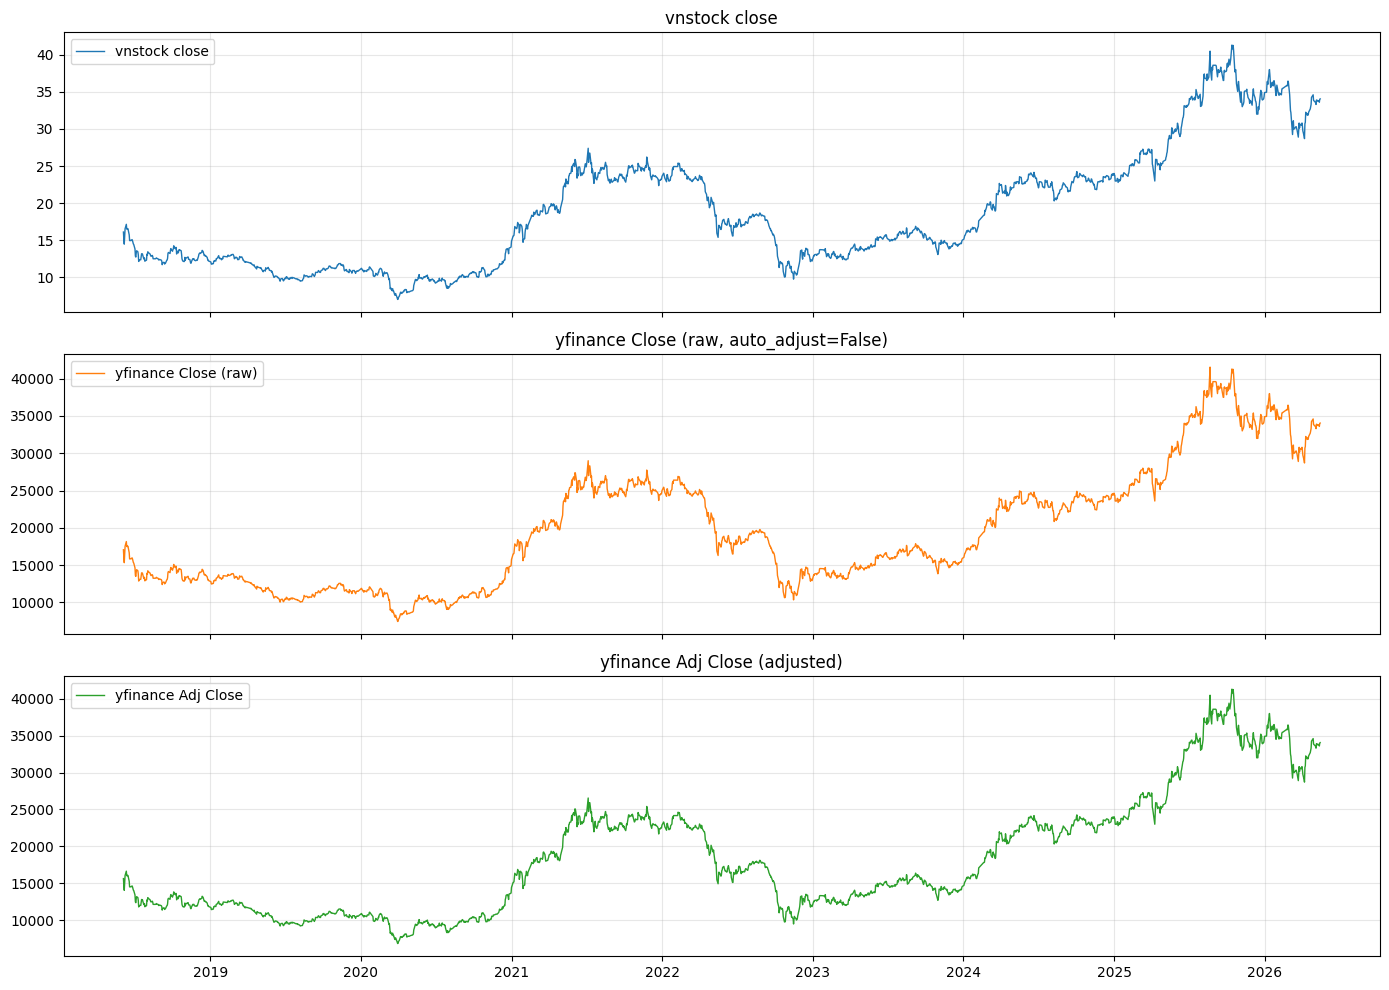

In [5]:
# Visual: 3-panel overlay
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(vn_close.index, vn_close.values, label='vnstock close', linewidth=1)
axes[0].set_title('vnstock close')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(yf_raw.index, yf_raw.values, label='yfinance Close (raw)', linewidth=1, color='C1')
axes[1].set_title('yfinance Close (raw, auto_adjust=False)')
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(yf_adj.index, yf_adj.values, label='yfinance Adj Close', linewidth=1, color='C2')
axes[2].set_title('yfinance Adj Close (adjusted)')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Cross-source agreement — scale-invariant check

vnstock VCI và yfinance dùng đơn vị khác nhau (nghìn VND vs VND, factor ≈ 1000), nên so sánh giá trị tuyệt đối `|vn − yf| / vn` cho con số vô nghĩa (≈ 99900%).

**Hai cách scale-invariant**:
- **(a)** Compute `factor = yf / vn` per date; spread của factor = real cross-source disagreement (sau khi loại scale)
- **(b)** So sánh **log returns** giữa 2 source — log return invariant với constant scale factor, nên 2 series identical-up-to-scale sẽ có lr_diff ≈ 0

Approach (b) là canonical cho Phase 0 threshold lock vì features L1-L2 đều dựa trên log returns.

In [6]:
# Two scales involved: vnstock VCI uses nghìn VND (thousands), yfinance uses VND.
# Naive |vn - yf| / vn gives ~99900% (≈ 1000x factor), not real disagreement.
# Two scale-invariant approaches:
#   (a) Compare LOG RETURNS — invariant to constant scale factor
#   (b) Normalize one source by inferred constant factor, then compare
# We do both for forensic clarity.

common_idx = vn_close.index.intersection(yf_adj.index)
print(f'Trading days chung: {len(common_idx):,}')
print(f'Chỉ có vnstock:     {len(vn_close.index.difference(yf_adj.index)):,}')
print(f'Chỉ có yfinance:    {len(yf_adj.index.difference(vn_close.index)):,}')

vn_aligned = vn_close.loc[common_idx]
yf_aligned = yf_adj.loc[common_idx]

# -------- (a) Scale factor inference --------
factor = yf_aligned / vn_aligned
print('\n[a] Inferred scale factor yf_aligned / vn_aligned:')
print(f'  median = {factor.median():.4f}')
print(f'  mean   = {factor.mean():.4f}')
print(f'  std    = {factor.std():.4f}')
print(f'  min    = {factor.min():.4f}')
print(f'  max    = {factor.max():.4f}')
print('  → If factor ≈ 1000 ± small, vnstock=nghìn VND and yfinance=VND')

# -------- (b) Log-return cross-source disagreement --------
vn_lr = np.log(vn_aligned / vn_aligned.shift(1)).dropna()
yf_lr = np.log(yf_aligned / yf_aligned.shift(1)).dropna()
common_lr_idx = vn_lr.index.intersection(yf_lr.index)
lr_diff = (vn_lr.loc[common_lr_idx] - yf_lr.loc[common_lr_idx]).abs()

print('\n[b] |log_return_vn - log_return_yf_adj|  (basis points, scale-invariant):')
for q in [0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 1.00]:
    print(f'  Q{q*100:5.1f}: {lr_diff.quantile(q)*10000:.4f} bp')
print(f'  Mean:    {lr_diff.mean()*10000:.4f} bp')
print(f'  Max:     {lr_diff.max()*10000:.4f} bp')
print('  (1 bp = 0.01% = 0.0001 in log-return space)')

Trading days chung: 1,982
Chỉ có vnstock:     3
Chỉ có yfinance:    0

[a] Inferred scale factor yf_aligned / vn_aligned:
  median = 968.9931
  mean   = 976.6093
  std    = 13.4438
  min    = 965.6458
  max    = 1000.2269
  → If factor ≈ 1000 ± small, vnstock=nghìn VND and yfinance=VND

[b] |log_return_vn - log_return_yf_adj|  (basis points, scale-invariant):
  Q 50.0: 1.5174 bp
  Q 75.0: 3.0129 bp
  Q 90.0: 4.6796 bp
  Q 95.0: 5.8374 bp
  Q 99.0: 8.2594 bp
  Q 99.9: 30.0885 bp
  Q100.0: 317.3940 bp
  Mean:    2.1910 bp
  Max:     317.3940 bp
  (1 bp = 0.01% = 0.0001 in log-return space)


In [7]:
# Top 10 disagreement days — based on log-return diff (scale-invariant)
worst_idx = lr_diff.sort_values(ascending=False).head(10).index
comparison = pd.DataFrame({
    'vn_close':       vn_aligned.loc[worst_idx],
    'yf_adj':         yf_aligned.loc[worst_idx],
    'vn_log_return':  vn_lr.loc[worst_idx],
    'yf_log_return':  yf_lr.loc[worst_idx],
    'lr_diff_bp':     lr_diff.loc[worst_idx] * 10000,
})
print('Top 10 ngày disagreement lớn nhất (cần investigate xem có pattern gì):')
display(comparison.round(4))

# Also list the dates only in vnstock
only_vn = vn_close.index.difference(yf_adj.index)
if len(only_vn) > 0:
    print(f'\nNgày vnstock có data nhưng yfinance thiếu ({len(only_vn)}):')
    print([str(d.date()) for d in only_vn])

Top 10 ngày disagreement lớn nhất (cần investigate xem có pattern gì):


,vn_close,yf_adj,vn_log_return,yf_log_return,lr_diff_bp
date,,,,,
2024-05-21,22.9900,22990.9688,-0.0211,0.0106,317.3940
2019-03-15,12.6800,12289.0996,-0.0055,-0.0019,36.4493
2019-03-14,12.7500,12311.9834,-0.0063,-0.0093,29.9587
2020-05-18,9.7500,9451.3936,0.0186,0.0196,9.2648
2019-08-13,9.7500,9451.3936,0.0186,0.0196,9.2648
2020-04-13,8.1300,7872.3462,0.0274,0.0265,9.2203
2020-08-04,8.9000,8627.5430,0.0124,0.0134,9.1479
2020-10-12,10.0100,9703.1250,-0.0080,-0.0071,9.0967
2020-06-04,10.0100,9703.1250,-0.0080,-0.0071,9.0967



Ngày vnstock có data nhưng yfinance thiếu (3):
['2024-08-27', '2024-10-30', '2024-11-05']


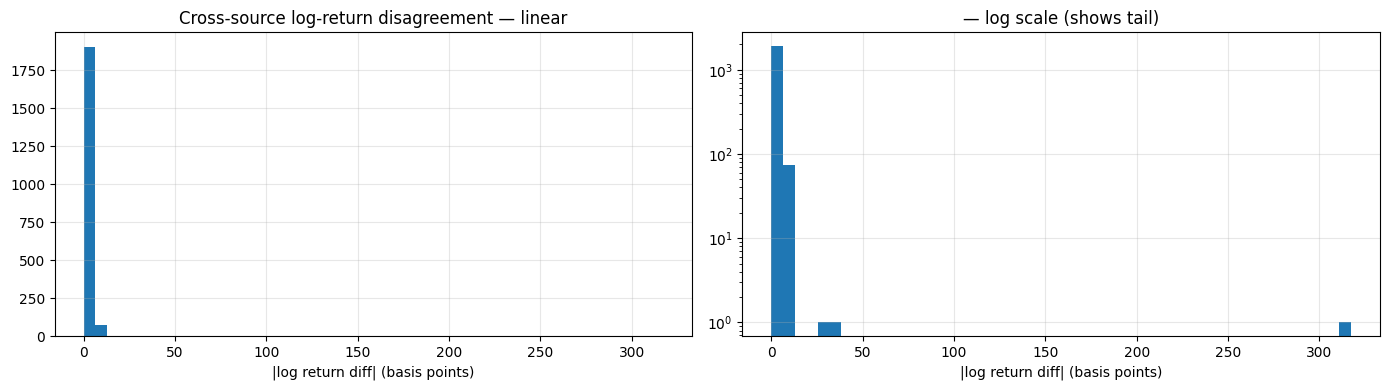

In [8]:
# Histograms of log-return disagreement (basis points)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
lr_bp = lr_diff.values * 10000

ax[0].hist(lr_bp, bins=50)
ax[0].set_xlabel('|log return diff| (basis points)')
ax[0].set_title('Cross-source log-return disagreement — linear')
ax[0].grid(alpha=0.3)

ax[1].hist(lr_bp, bins=50, log=True)
ax[1].set_xlabel('|log return diff| (basis points)')
ax[1].set_title('— log scale (shows tail)')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Trading calendar gap analysis

HOSE nghỉ theo lịch nhà nước VN. Gap lớn nhất là Tết Nguyên đán (~ 9-11 calendar days). Bất kỳ gap > 14 calendar days = anomaly cần investigate.

Phân tích này feed vào threshold cho summary stats trong fetchers (gap reporting, không phải hard error trong Session 1).

In [9]:
gaps = vn_close.index.to_series().diff().dt.days.dropna()
print('Distribution of calendar-day gaps between consecutive trading days (vnstock):')
print(gaps.value_counts().sort_index().head(15))

print('\nTop 10 longest gaps:')
gap_dates = pd.DataFrame({
    'gap_days': gaps.values,
    'after_date': gaps.index,
    'before_date': gaps.index - pd.to_timedelta(gaps.values, unit='D'),
})
display(gap_dates.sort_values('gap_days', ascending=False).head(10))

Distribution of calendar-day gaps between consecutive trading days (vnstock):
date
1.0000     1568
2.0000        6
3.0000      377
4.0000       10
5.0000       11
6.0000        4
8.0000        4
10.0000       4
Name: count, dtype: int64

Top 10 longest gaps:


,gap_days,after_date,before_date
1927,10.0000,2026-02-23,2026-02-13
919,10.0000,2022-02-07,2022-01-28
1665,10.0000,2025-02-03,2025-01-24
171,10.0000,2019-02-11,2019-02-01
413,8.0000,2020-01-30,2020-01-22
1425,8.0000,2024-02-15,2024-02-07
1162,8.0000,2023-01-27,2023-01-19
677,8.0000,2021-02-17,2021-02-09
1228,6.0000,2023-05-04,2023-04-28
225,6.0000,2019-05-02,2019-04-26


## 5. Kết luận và hành động

Sau khi inspect các kết quả ở trên, điền vào sections sau:

### 5.1 Open Q1 resolution

- [ ] vnstock VCI close = **adjusted** close (research_design 2.3 assumption ✓)
- [ ] vnstock VCI close = **unadjusted** close → cần chuyển sang TCBS source hoặc apply manual adjustment
- [ ] Inconclusive (không có corporate action lớn trong range)

### 5.2 Cross-source threshold cho fetcher

Dựa vào Q99 của relative diff distribution: lock threshold = `{ROUND_UP từ Q99}` trong fetcher cross-check.

Q99 quan sát: _____ %  →  threshold đề xuất: _____ %

### 5.3 Trading day gap threshold

Max gap quan sát: _____ calendar days (tại date _____)

→ Trong summary report của fetchers, flag WARN nếu gap > _____ days.

### 5.4 Update IMPLEMENTATION.md

Thêm vào CHANGELOG.md hoặc IMPLEMENTATION.md (CHANGELOG entry):

```
## [0.2.0] - 2026-05-XX
### Resolved
- Open Q1: vnstock VCI close là [adjusted/unadjusted]. Evidence trong notebook 00.
- Cross-source threshold lock at X.X% based on Q99 of observed relative diff.
- Max calendar-day gap baseline: N days at YYYY-MM-DD (likely Tết YYYY).
```

Sau đó báo cho tôi (Claude) trong session sau để update IMPLEMENTATION.md formally.